**Importing Required Libraries:**

In [2]:
import numpy as np
import pandas as pd
import os
import time
import pickle
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict

In [3]:
!pip install kagglehub

In [4]:
import kagglehub
path = kagglehub.dataset_download("swaroopkml/cifar10-pngs-in-folders")

100%|██████████| 140M/140M [00:02<00:00, 68.0MB/s]

Extracting files...


In [5]:
import os
print(os.listdir(path))

['cifar10']


**Configuration:**

In [6]:
DATASET_PATH = path + "/cifar10/cifar10"
IMG_SIZE     = 32
NUM_CLASSES  = 10
BATCH_SIZE   = 64
EPOCHS       = 15
LR           = 0.001
SAVE_PATH    = "/content/cnn_weights.pkl"

CLASS_NAMES = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

In [7]:
import os
print(os.listdir(DATASET_PATH))

['train', 'test']


In [8]:
print(os.listdir(DATASET_PATH + "/train"))

['dog', 'horse', 'bird', 'truck', 'deer', 'ship', 'cat', 'frog', 'airplane', 'automobile']


**Data Loading & Augmentation:**

In [9]:
def load_images_from_folder(root, split="train", img_size=32, max_per_class=None):
    X, y = [], []
    split_path = os.path.join(root, split)
    for label, class_name in enumerate(CLASS_NAMES):
        class_path = os.path.join(split_path, class_name)
        if not os.path.exists(class_path):
            print(f"  WARNING: {class_path} not found, skipping.")
            continue
        files = [f for f in os.listdir(class_path)
                 if f.lower().endswith(('.png','.jpg','.jpeg'))]
        if max_per_class:
            files = files[:max_per_class]
        for fname in files:
            img = Image.open(os.path.join(class_path, fname)).convert("RGB")
            img = img.resize((img_size, img_size))
            X.append(np.array(img, dtype=np.float32))
            y.append(label)
    X = np.array(X)
    y = np.array(y, dtype=np.int32)
    return X, y

In [10]:
def preprocess(X_train, X_test):
    mean = X_train.mean(axis=(0,1,2), keepdims=True)
    std  = X_train.std(axis=(0,1,2),  keepdims=True) + 1e-7
    X_train = (X_train - mean) / std
    X_test  = (X_test  - mean) / std
    X_train = X_train.transpose(0,3,1,2)
    X_test  = X_test.transpose(0,3,1,2)
    return X_train.astype(np.float32), X_test.astype(np.float32)

In [11]:
def augment_batch(X):
    N, C, H, W = X.shape
    out = X.copy()
    for i in range(N):
        if np.random.rand() < 0.5:
            out[i] = out[i, :, :, ::-1]
        pad = 4
        padded = np.pad(out[i], ((0,0),(pad,pad),(pad,pad)), mode='reflect')
        r = np.random.randint(0, 2*pad)
        c = np.random.randint(0, 2*pad)
        out[i] = padded[:, r:r+H, c:c+W]
        out[i] = out[i] * np.random.uniform(0.85, 1.15)
    return out

In [12]:
def one_hot(y, num_classes=10):
    oh = np.zeros((len(y), num_classes), dtype=np.float32)
    oh[np.arange(len(y)), y] = 1.0
    return oh

In [13]:
def batch_generator(X, y, batch_size, shuffle=True, augment=False):
    N = X.shape[0]
    idx = np.arange(N)
    if shuffle:
        np.random.shuffle(idx)
    for start in range(0, N, batch_size):
        batch_idx = idx[start:start+batch_size]
        Xb = X[batch_idx]
        yb = y[batch_idx]
        if augment:
            Xb = augment_batch(Xb)
        yield Xb, yb

**Implementation of Layers:**

In [14]:
class Conv2D:
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.ks      = kernel_size
        self.stride  = stride
        self.padding = padding
        fan_in = in_channels * kernel_size * kernel_size
        self.W = np.random.randn(out_channels, in_channels,
                                 kernel_size, kernel_size).astype(np.float32) * np.sqrt(2.0/fan_in)
        self.b  = np.zeros(out_channels, dtype=np.float32)
        self.mW = np.zeros_like(self.W); self.vW = np.zeros_like(self.W)
        self.mb = np.zeros_like(self.b); self.vb = np.zeros_like(self.b)
        self.t  = 0

    @staticmethod
    def _im2col(X, kh, kw, stride, padding):
        N, C, H, W = X.shape
        Xp = np.pad(X, ((0,0),(0,0),(padding,padding),(padding,padding)), mode='constant')
        out_h = (H + 2*padding - kh)//stride + 1
        out_w = (W + 2*padding - kw)//stride + 1
        col = np.zeros((N, C, kh, kw, out_h, out_w), dtype=X.dtype)
        for r in range(kh):
            r_max = r + stride*out_h
            for c in range(kw):
                c_max = c + stride*out_w
                col[:, :, r, c, :, :] = Xp[:, :, r:r_max:stride, c:c_max:stride]
        return col.transpose(0,4,5,1,2,3).reshape(N*out_h*out_w, -1), out_h, out_w

    @staticmethod
    def _col2im(col, X_shape, kh, kw, stride, padding):
        N, C, H, W = X_shape
        out_h = (H + 2*padding - kh)//stride + 1
        out_w = (W + 2*padding - kw)//stride + 1
        col   = col.reshape(N, out_h, out_w, C, kh, kw).transpose(0,3,4,5,1,2)
        Xp    = np.zeros((N, C, H+2*padding+stride-1, W+2*padding+stride-1), dtype=col.dtype)
        for r in range(kh):
            r_max = r + stride*out_h
            for c in range(kw):
                c_max = c + stride*out_w
                Xp[:, :, r:r_max:stride, c:c_max:stride] += col[:, :, r, c, :, :]
        return Xp[:, :, padding:padding+H, padding:padding+W]

    def forward(self, X):
        self.X_shape = X.shape
        N, C, H, W = X.shape
        col, out_h, out_w = self._im2col(X, self.ks, self.ks, self.stride, self.padding)
        self.col = col
        W_col = self.W.reshape(self.out_channels, -1)
        out   = col @ W_col.T + self.b
        return out.reshape(N, out_h, out_w, self.out_channels).transpose(0,3,1,2)

    def backward(self, dout):
        N, F, out_h, out_w = dout.shape
        dout_r = dout.transpose(0,2,3,1).reshape(-1, F)
        W_col  = self.W.reshape(F, -1)
        self.dW = (dout_r.T @ self.col).reshape(self.W.shape)
        self.db = dout_r.sum(axis=0)
        dcol    = dout_r @ W_col
        return self._col2im(dcol, self.X_shape, self.ks, self.ks, self.stride, self.padding)

    def update(self, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for (p,dp,m,v) in [(self.W,self.dW,self.mW,self.vW),(self.b,self.db,self.mb,self.vb)]:
            m[:] = beta1*m + (1-beta1)*dp
            v[:] = beta2*v + (1-beta2)*dp**2
            p   -= lr * (m/(1-beta1**self.t)) / (np.sqrt(v/(1-beta2**self.t)) + eps)

    def get_params(self):
        return {'W':self.W,'b':self.b,'mW':self.mW,'vW':self.vW,'mb':self.mb,'vb':self.vb,'t':self.t}
    def set_params(self,d):
        self.W=d['W'];self.b=d['b'];self.mW=d['mW'];self.vW=d['vW'];self.mb=d['mb'];self.vb=d['vb'];self.t=d['t']

**Batch Normalization:**

In [15]:
class BatchNorm:
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        self.eps=eps; self.momentum=momentum
        self.gamma=np.ones(num_features,dtype=np.float32)
        self.beta=np.zeros(num_features,dtype=np.float32)
        self.running_mean=np.zeros(num_features,dtype=np.float32)
        self.running_var=np.ones(num_features,dtype=np.float32)
        self.mg=np.zeros_like(self.gamma);self.vg=np.zeros_like(self.gamma)
        self.mb=np.zeros_like(self.beta); self.vb=np.zeros_like(self.beta)
        self.t=0; self.training=True

    def forward(self, X):
        self._4d = (X.ndim==4)
        if self._4d:
            N,C,H,W = X.shape
            Xr = X.transpose(1,0,2,3).reshape(C,-1)
        else:
            Xr = X.T
        if self.training:
            mean = Xr.mean(axis=1,keepdims=True)
            var  = Xr.var(axis=1, keepdims=True)
            self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*mean.squeeze()
            self.running_var  = (1-self.momentum)*self.running_var  + self.momentum*var.squeeze()
        else:
            mean = self.running_mean[:,None]
            var  = self.running_var[:,None]
        self.Xnorm = (Xr-mean)/np.sqrt(var+self.eps); self.var=var
        out = self.gamma[:,None]*self.Xnorm + self.beta[:,None]
        if self._4d:
            N,C,H,W = X.shape
            return out.reshape(C,N,H,W).transpose(1,0,2,3)
        return out.T

    def backward(self, dout):
        if self._4d:
            N,C,H,W=dout.shape; dout_r=dout.transpose(1,0,2,3).reshape(C,-1)
        else: dout_r=dout.T
        M=dout_r.shape[1]
        self.dgamma=(dout_r*self.Xnorm).sum(axis=1); self.dbeta=dout_r.sum(axis=1)
        dXnorm=self.gamma[:,None]*dout_r
        dvar=(dXnorm*(self.Xnorm*-0.5/(self.var+self.eps))).sum(axis=1,keepdims=True)
        dmean=(dXnorm*-1/np.sqrt(self.var+self.eps)).sum(axis=1,keepdims=True)
        dX=dXnorm/np.sqrt(self.var+self.eps)+dvar*2*(dout_r-dout_r.mean(axis=1,keepdims=True))/M+dmean/M
        if self._4d: return dX.reshape(C,N,H,W).transpose(1,0,2,3)
        return dX.T

    def update(self, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t+=1
        for (p,dp,m,v) in [(self.gamma,self.dgamma,self.mg,self.vg),(self.beta,self.dbeta,self.mb,self.vb)]:
            m[:]=beta1*m+(1-beta1)*dp; v[:]=beta2*v+(1-beta2)*dp**2
            p-=lr*(m/(1-beta1**self.t))/(np.sqrt(v/(1-beta2**self.t))+eps)

    def get_params(self):
        return dict(gamma=self.gamma,beta=self.beta,running_mean=self.running_mean,
                    running_var=self.running_var,mg=self.mg,vg=self.vg,mb=self.mb,vb=self.vb,t=self.t)
    def set_params(self,d):
        self.gamma=d['gamma'];self.beta=d['beta'];self.running_mean=d['running_mean']
        self.running_var=d['running_var'];self.mg=d['mg'];self.vg=d['vg'];self.mb=d['mb'];self.vb=d['vb'];self.t=d['t']

**Relu Activation Function:**

In [16]:
class ReLU:
    def forward(self, X):
        self.mask = X > 0
        return X * self.mask
    def backward(self, dout):
        return dout * self.mask

**Applying Pooling (MAX POOLING):**

In [17]:
class MaxPool2D:
    def __init__(self, pool_size=2, stride=2):
        self.ps = pool_size
        self.stride = stride

    def forward(self, X):
        N, C, H, W = X.shape
        out_h = (H - self.ps)//self.stride + 1
        out_w = (W - self.ps)//self.stride + 1
        self.X = X
        out = np.zeros((N, C, out_h, out_w), dtype=X.dtype)
        for r in range(out_h):
            for c in range(out_w):
                patch = X[:, :,
                          r*self.stride:r*self.stride+self.ps,
                          c*self.stride:c*self.stride+self.ps]
                out[:,:,r,c] = patch.max(axis=(2,3))
        return out

    def backward(self, dout):
        N, C, H, W = self.X.shape
        out_h = (H - self.ps)//self.stride + 1
        out_w = (W - self.ps)//self.stride + 1
        dX = np.zeros_like(self.X)
        for r in range(out_h):
            for c in range(out_w):
                patch = self.X[:, :,
                               r*self.stride:r*self.stride+self.ps,
                               c*self.stride:c*self.stride+self.ps]
                maxval = patch.max(axis=(2,3), keepdims=True)
                mask   = (patch == maxval)
                dX[:, :,
                   r*self.stride:r*self.stride+self.ps,
                   c*self.stride:c*self.stride+self.ps] += (
                    mask * dout[:,:,r:r+1,c:c+1] / mask.sum(axis=(2,3),keepdims=True))
        return dX

In [18]:
class Flatten:
    def forward(self, X):
        self.shape = X.shape
        return X.reshape(X.shape[0], -1)
    def backward(self, dout):
        return dout.reshape(self.shape)

In [19]:
class Linear:
    def __init__(self, in_features, out_features):
        self.W = np.random.randn(in_features, out_features
                                 ).astype(np.float32) * np.sqrt(2.0/in_features)
        self.b = np.zeros(out_features, dtype=np.float32)
        self.mW=np.zeros_like(self.W); self.vW=np.zeros_like(self.W)
        self.mb=np.zeros_like(self.b); self.vb=np.zeros_like(self.b)
        self.t=0

    def forward(self, X):
        self.X = X
        return X @ self.W + self.b

    def backward(self, dout):
        self.dW = self.X.T @ dout
        self.db = dout.sum(axis=0)
        return dout @ self.W.T

    def update(self, lr, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for (p,dp,m,v) in [(self.W,self.dW,self.mW,self.vW),
                           (self.b,self.db,self.mb,self.vb)]:
            m[:] = beta1*m + (1-beta1)*dp
            v[:] = beta2*v + (1-beta2)*dp**2
            m_hat = m / (1-beta1**self.t)
            v_hat = v / (1-beta2**self.t)
            p    -= lr * m_hat / (np.sqrt(v_hat) + eps)

    def get_params(self):
        return dict(W=self.W,b=self.b,
                    mW=self.mW,vW=self.vW,mb=self.mb,vb=self.vb,t=self.t)
    def set_params(self,d):
        self.W=d['W']; self.b=d['b']
        self.mW=d['mW']; self.vW=d['vW']
        self.mb=d['mb']; self.vb=d['vb']; self.t=d['t']

In [20]:
class Dropout:
    def __init__(self,p=0.5): self.p=p; self.training=True
    def forward(self,X):
        if not self.training: return X
        self.mask=(np.random.rand(*X.shape)>self.p).astype(np.float32)
        return X*self.mask/(1-self.p)
    def backward(self,dout):
        if not self.training: return dout
        return dout*self.mask/(1-self.p)

**Loss: Softmax + CrossEntropy**

In [21]:
def softmax_crossentropy_forward(logits, y_oh):
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp_s   = np.exp(shifted)
    probs   = exp_s / exp_s.sum(axis=1, keepdims=True)
    N       = logits.shape[0]
    log_likelihood = -np.log(probs[y_oh.astype(bool)] + 1e-9)
    loss    = log_likelihood.mean()
    return loss, probs

In [22]:
def softmax_crossentropy_backward(probs, y_oh):
    N     = probs.shape[0]
    dlogits = probs.copy()
    dlogits[y_oh.astype(bool)] -= 1
    return dlogits / N

**Model Implementation:**

In [23]:
class CNN:
    """
    Architecture:
      Conv(3→32,3×3) → BN → ReLU → Conv(32→32,3×3) → BN → ReLU → MaxPool → Dropout(0.25)
      Conv(32→64,3×3) → BN → ReLU → Conv(64→64,3×3) → BN → ReLU → MaxPool → Dropout(0.25)
      Conv(64→128,3×3) → BN → ReLU → MaxPool → Dropout(0.25)
      Flatten → FC(2048→512) → BN → ReLU → Dropout(0.5)
      FC(512→10)

    Input: (N, 3, 32, 32)  →  Output: (N, 10) logits
    """
    def __init__(self):
        # Block 1
        self.conv1 = Conv2D(3,  32, 3, padding=1)
        self.bn1   = BatchNorm(32)
        self.relu1 = ReLU()
        self.conv2 = Conv2D(32, 32, 3, padding=1)
        self.bn2   = BatchNorm(32)
        self.relu2 = ReLU()
        self.pool1 = MaxPool2D()
        self.drop1 = Dropout(0.25)

        # Block 2
        self.conv3 = Conv2D(32, 64, 3, padding=1)
        self.bn3   = BatchNorm(64)
        self.relu3 = ReLU()
        self.conv4 = Conv2D(64, 64, 3, padding=1)
        self.bn4   = BatchNorm(64)
        self.relu4 = ReLU()
        self.pool2 = MaxPool2D()
        self.drop2 = Dropout(0.25)

        # Block 3
        self.conv5 = Conv2D(64, 128, 3, padding=1)
        self.bn5   = BatchNorm(128)
        self.relu5 = ReLU()
        self.pool3 = MaxPool2D()
        self.drop3 = Dropout(0.25)

        # Head
        self.flatten = Flatten()
        self.fc1     = Linear(128*4*4, 512)   # 32→16→8→4 after 3 pools
        self.bn6     = BatchNorm(512)
        self.relu6   = ReLU()
        self.drop4   = Dropout(0.5)
        self.fc2     = Linear(512, NUM_CLASSES)

        # All learnable layers for easy iteration
        self._learnable = [self.conv1,self.bn1,self.conv2,self.bn2,
                           self.conv3,self.bn3,self.conv4,self.bn4,
                           self.conv5,self.bn5,
                           self.fc1,  self.bn6, self.fc2]
        # All batch-norm + dropout layers (need training flag)
        self._bn_layers  = [self.bn1,self.bn2,self.bn3,
                            self.bn4,self.bn5,self.bn6]
        self._drop_layers= [self.drop1,self.drop2,self.drop3,self.drop4]

    def set_training(self, flag):
        for bn in self._bn_layers:  bn.training = flag
        for dp in self._drop_layers: dp.training = flag

    def forward(self, X):
        # Block 1
        x = self.relu1.forward(self.bn1.forward(self.conv1.forward(X)))
        x = self.relu2.forward(self.bn2.forward(self.conv2.forward(x)))
        x = self.drop1.forward(self.pool1.forward(x))
        # Block 2
        x = self.relu3.forward(self.bn3.forward(self.conv3.forward(x)))
        x = self.relu4.forward(self.bn4.forward(self.conv4.forward(x)))
        x = self.drop2.forward(self.pool2.forward(x))
        # Block 3
        x = self.relu5.forward(self.bn5.forward(self.conv5.forward(x)))
        x = self.drop3.forward(self.pool3.forward(x))
        # Head
        x = self.flatten.forward(x)
        x = self.relu6.forward(self.bn6.forward(self.fc1.forward(x)))
        x = self.drop4.forward(x)
        x = self.fc2.forward(x)
        return x

    def backward(self, dlogits):
        d = self.fc2.backward(dlogits)
        d = self.drop4.backward(d)
        d = self.fc1.backward(self.bn6.backward(self.relu6.backward(d)))
        d = self.flatten.backward(d)
        # Block 3
        d = self.pool3.backward(self.drop3.backward(d))
        d = self.conv5.backward(self.bn5.backward(self.relu5.backward(d)))
        # Block 2
        d = self.pool2.backward(self.drop2.backward(d))
        d = self.conv4.backward(self.bn4.backward(self.relu4.backward(d)))
        d = self.conv3.backward(self.bn3.backward(self.relu3.backward(d)))
        # Block 1
        d = self.pool1.backward(self.drop1.backward(d))
        d = self.conv2.backward(self.bn2.backward(self.relu2.backward(d)))
        d = self.conv1.backward(self.bn1.backward(self.relu1.backward(d)))
        return d

    def update(self, lr):
        for layer in self._learnable:
            layer.update(lr)

    def save(self, path):
        state = {name: layer.get_params()
                 for name, layer in self._named_learnable()}
        with open(path, 'wb') as f:
            pickle.dump(state, f)
        print(f"  Weights saved → {path}")

    def load(self, path):
        with open(path, 'rb') as f:
            state = pickle.load(f)
        for name, layer in self._named_learnable():
            if name in state:
                layer.set_params(state[name])
        print(f"  Weights loaded ← {path}")

    def _named_learnable(self):
        return [('conv1',self.conv1),('bn1',self.bn1),
                ('conv2',self.conv2),('bn2',self.bn2),
                ('conv3',self.conv3),('bn3',self.bn3),
                ('conv4',self.conv4),('bn4',self.bn4),
                ('conv5',self.conv5),('bn5',self.bn5),
                ('fc1',  self.fc1), ('bn6',self.bn6),
                ('fc2',  self.fc2)]

**Learning Rate Schedule:**

In [24]:
def cosine_lr(base_lr, epoch, total_epochs):
    return base_lr * 0.5 * (1 + np.cos(np.pi * epoch / total_epochs))

**Training Loop:**

In [25]:
def compute_accuracy(model, X, y, batch_size=256):
    model.set_training(False)
    correct = total = 0
    for Xb, yb in batch_generator(X, y, batch_size, shuffle=False, augment=False):
        logits = model.forward(Xb)
        preds  = logits.argmax(axis=1)
        correct += (preds == yb).sum()
        total   += len(yb)
    model.set_training(True)
    return correct / total

In [26]:
def train(model, X_train, y_train, X_test, y_test):
    history = defaultdict(list)
    best_acc = 0.0

    y_oh_train = one_hot(y_train)

    for epoch in range(1, EPOCHS+1):
        lr = cosine_lr(LR, epoch-1, EPOCHS)
        model.set_training(True)

        epoch_loss = 0.0
        epoch_correct = 0
        epoch_total   = 0
        t0 = time.time()

        for Xb, yb in batch_generator(X_train, y_train, BATCH_SIZE,
                                       shuffle=True, augment=True):
            yb_oh = one_hot(yb)
            # Forward
            logits = model.forward(Xb)
            loss, probs = softmax_crossentropy_forward(logits, yb_oh)
            # Backward
            dlogits = softmax_crossentropy_backward(probs, yb_oh)
            model.backward(dlogits)
            model.update(lr)

            epoch_loss    += loss * len(yb)
            epoch_correct += (logits.argmax(1) == yb).sum()
            epoch_total   += len(yb)

        train_loss = epoch_loss    / epoch_total
        train_acc  = epoch_correct / epoch_total
        val_acc    = compute_accuracy(model, X_test, y_test)
        elapsed    = time.time() - t0

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch:02d}/{EPOCHS}  "
              f"lr={lr:.5f}  loss={train_loss:.4f}  "
              f"train_acc={train_acc*100:.2f}%  "
              f"val_acc={val_acc*100:.2f}%  "
              f"time={elapsed:.1f}s")

        if val_acc > best_acc:
            best_acc = val_acc
            model.save(SAVE_PATH)
            print(f"  ★ New best val_acc={best_acc*100:.2f}% — weights saved!")

    print(f"\nTraining complete. Best validation accuracy: {best_acc*100:.2f}%")
    return history

**Testing & Evaluation:**

In [27]:
def evaluate(model, X_test, y_test, batch_size=256):
    model.set_training(False)

    all_preds = []
    all_probs = []
    for Xb, yb in batch_generator(X_test, y_test, batch_size,
                                   shuffle=False, augment=False):
        logits = model.forward(Xb)
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp_s   = np.exp(shifted)
        probs   = exp_s / exp_s.sum(axis=1, keepdims=True)
        all_preds.extend(logits.argmax(axis=1).tolist())
        all_probs.extend(probs.tolist())

    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    overall_acc = (all_preds == y_test).mean()
    print(f"\n{'='*50}")
    print(f"  TEST ACCURACY : {overall_acc*100:.2f}%")
    print(f"{'='*50}")

    print("\nPer-class accuracy:")
    conf = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
    for t, p in zip(y_test, all_preds):
        conf[t][p] += 1

    for i, cname in enumerate(CLASS_NAMES):
        cls_acc = conf[i,i] / conf[i].sum() if conf[i].sum() > 0 else 0
        print(f"  {cname:<12} : {cls_acc*100:.1f}%  ({conf[i,i]}/{conf[i].sum()})")

    return overall_acc, conf, all_preds, all_probs

In [28]:
def plot_results(history, conf, X_test, y_test, all_preds):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("CNN from Scratch – CIFAR-10 Results", fontsize=14, fontweight='bold')

    # 1. Loss curve
    ax = axes[0,0]
    ax.plot(history['train_loss'], label='Train Loss', color='tomato')
    ax.set_title("Training Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True, alpha=0.3)

    # 2. Accuracy curve
    ax = axes[0,1]
    ax.plot([a*100 for a in history['train_acc']], label='Train Acc', color='steelblue')
    ax.plot([a*100 for a in history['val_acc']],   label='Val Acc',   color='darkorange')
    ax.set_title("Accuracy"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(); ax.grid(True, alpha=0.3)

    # 3. Confusion matrix
    ax = axes[1,0]
    im = ax.imshow(conf, interpolation='nearest', cmap='Blues')
    ax.set_title("Confusion Matrix")
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, str(conf[i,j]), ha='center', va='center',
                    fontsize=7, color='white' if conf[i,j] > conf.max()*0.5 else 'black')
    plt.colorbar(im, ax=ax)

    # 4. Sample predictions (first 16 test images)
    ax = axes[1,1]
    ax.axis('off')
    # show a mini grid of 16 images using imshow
    sample_ax = fig.add_axes([0.52, 0.05, 0.46, 0.42])
    sample_ax.axis('off')
    sample_ax.set_title("Sample Predictions (green=correct, red=wrong)", fontsize=9)

    grid_size = 4
    canvas = np.ones((grid_size*36, grid_size*36, 3), dtype=np.uint8)*240
    for idx in range(min(16, len(X_test))):
        row, col = divmod(idx, grid_size)
        # X_test is (N,C,H,W) normalised; convert back approximately
        img = X_test[idx].transpose(1,2,0)  # CHW→HWC
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        img = (img * 255).astype(np.uint8)
        img_resized = np.array(Image.fromarray(img).resize((32,32)))
        # color border
        border_color = [0,200,0] if y_test[idx]==all_preds[idx] else [200,0,0]
        patch = np.ones((36,36,3), dtype=np.uint8)
        patch[:] = border_color
        patch[2:34,2:34] = img_resized
        canvas[row*36:(row+1)*36, col*36:(col+1)*36] = patch

    sample_ax.imshow(canvas)

    plt.tight_layout()
    plt.savefig("cnn_results.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("\nPlot saved as cnn_results.png")

**Gradient Check:**

In [29]:
def gradient_check(model, X_small, y_small, eps=1e-4, num_checks=5):
    """Quick sanity check on a tiny batch."""
    print("\nRunning gradient check on FC2 weights (first few)...")
    model.set_training(False)
    y_oh = one_hot(y_small)

    logits = model.forward(X_small)
    _, probs = softmax_crossentropy_forward(logits, y_oh)
    dlogits  = softmax_crossentropy_backward(probs, y_oh)
    model.backward(dlogits)
    analytic = model.fc2.dW.flatten()[:num_checks].copy()

    numeric = np.zeros(num_checks)
    W_flat  = model.fc2.W.flatten()
    for i in range(num_checks):
        W_flat[i] += eps
        model.fc2.W = W_flat.reshape(model.fc2.W.shape)
        logits_p = model.forward(X_small)
        loss_p,_ = softmax_crossentropy_forward(logits_p, y_oh)

        W_flat[i] -= 2*eps
        model.fc2.W = W_flat.reshape(model.fc2.W.shape)
        logits_m = model.forward(X_small)
        loss_m,_ = softmax_crossentropy_forward(logits_m, y_oh)

        numeric[i] = (loss_p - loss_m) / (2*eps)
        W_flat[i] += eps

    model.fc2.W = W_flat.reshape(model.fc2.W.shape)
    model.set_training(True)

    rel_err = np.abs(analytic - numeric) / (np.abs(analytic) + np.abs(numeric) + 1e-10)
    print(f"  Analytic : {analytic}")
    print(f"  Numeric  : {numeric}")
    print(f"  Rel error: {rel_err}  (should be < 1e-4 to be healthy)")

**Actual Implementation Part:**

**Load Data:**

In [62]:
np.random.seed(42)

print("Loading training data...")
X_train, y_train = load_images_from_folder(DATASET_PATH, split="train",img_size=IMG_SIZE,max_per_class=350)
print(f"  Train: {X_train.shape}, labels: {y_train.shape}")

print("Loading test data...")
X_test, y_test = load_images_from_folder(DATASET_PATH, split="test",img_size=IMG_SIZE,max_per_class=50)
print(f"  Test : {X_test.shape}, labels: {y_test.shape}")

Loading training data...
  Train: (3500, 32, 32, 3), labels: (3500,)
Loading test data...
  Test : (500, 32, 32, 3), labels: (500,)


**Preprocess:**

In [63]:
print("Preprocessing...")
X_train, X_test = preprocess(X_train, X_test)
print(f"  X_train shape: {X_train.shape}  dtype: {X_train.dtype}")

Preprocessing...
  X_train shape: (3500, 3, 32, 32)  dtype: float32


**Build Model:**

In [64]:
model = CNN()
print("Architecture: Input(3,32,32) → Conv×2→Pool → Conv×2→Pool → Conv→Pool → FC(512) → FC(10)")

Architecture: Input(3,32,32) → Conv×2→Pool → Conv×2→Pool → Conv→Pool → FC(512) → FC(10)


**Train:**

In [65]:
print(f"Starting training for {EPOCHS} epochs...\n")
history = train(model, X_train, y_train, X_test, y_test)

Starting training for 15 epochs...

Epoch 01/15  lr=0.00100  loss=2.4692  train_acc=21.54%  val_acc=16.40%  time=163.1s
  Weights saved → /content/cnn_weights.pkl
  ★ New best val_acc=16.40% — weights saved!
Epoch 02/15  lr=0.00099  loss=2.1175  train_acc=28.97%  val_acc=21.60%  time=147.8s
  Weights saved → /content/cnn_weights.pkl
  ★ New best val_acc=21.60% — weights saved!
Epoch 03/15  lr=0.00096  loss=1.9680  train_acc=32.71%  val_acc=28.80%  time=148.0s
  Weights saved → /content/cnn_weights.pkl
  ★ New best val_acc=28.80% — weights saved!
Epoch 04/15  lr=0.00090  loss=1.8549  train_acc=36.11%  val_acc=31.80%  time=149.0s
  Weights saved → /content/cnn_weights.pkl
  ★ New best val_acc=31.80% — weights saved!
Epoch 05/15  lr=0.00083  loss=1.7440  train_acc=39.37%  val_acc=34.60%  time=153.8s
  Weights saved → /content/cnn_weights.pkl
  ★ New best val_acc=34.60% — weights saved!
Epoch 06/15  lr=0.00075  loss=1.6829  train_acc=40.09%  val_acc=42.80%  time=149.2s
  Weights saved → /c

**Load Best Weights & Evaluate:**

In [66]:
model.set_training(False)
overall_acc, conf, all_preds, all_probs = evaluate(model, X_test, y_test)


  TEST ACCURACY : 45.20%

Per-class accuracy:
  airplane     : 20.0%  (10/50)
  automobile   : 38.0%  (19/50)
  bird         : 18.0%  (9/50)
  cat          : 28.0%  (14/50)
  deer         : 68.0%  (34/50)
  dog          : 26.0%  (13/50)
  frog         : 82.0%  (41/50)
  horse        : 10.0%  (5/50)
  ship         : 82.0%  (41/50)
  truck        : 80.0%  (40/50)


**Plot Results:**

/tmp/ipython-input-176/1358144394.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


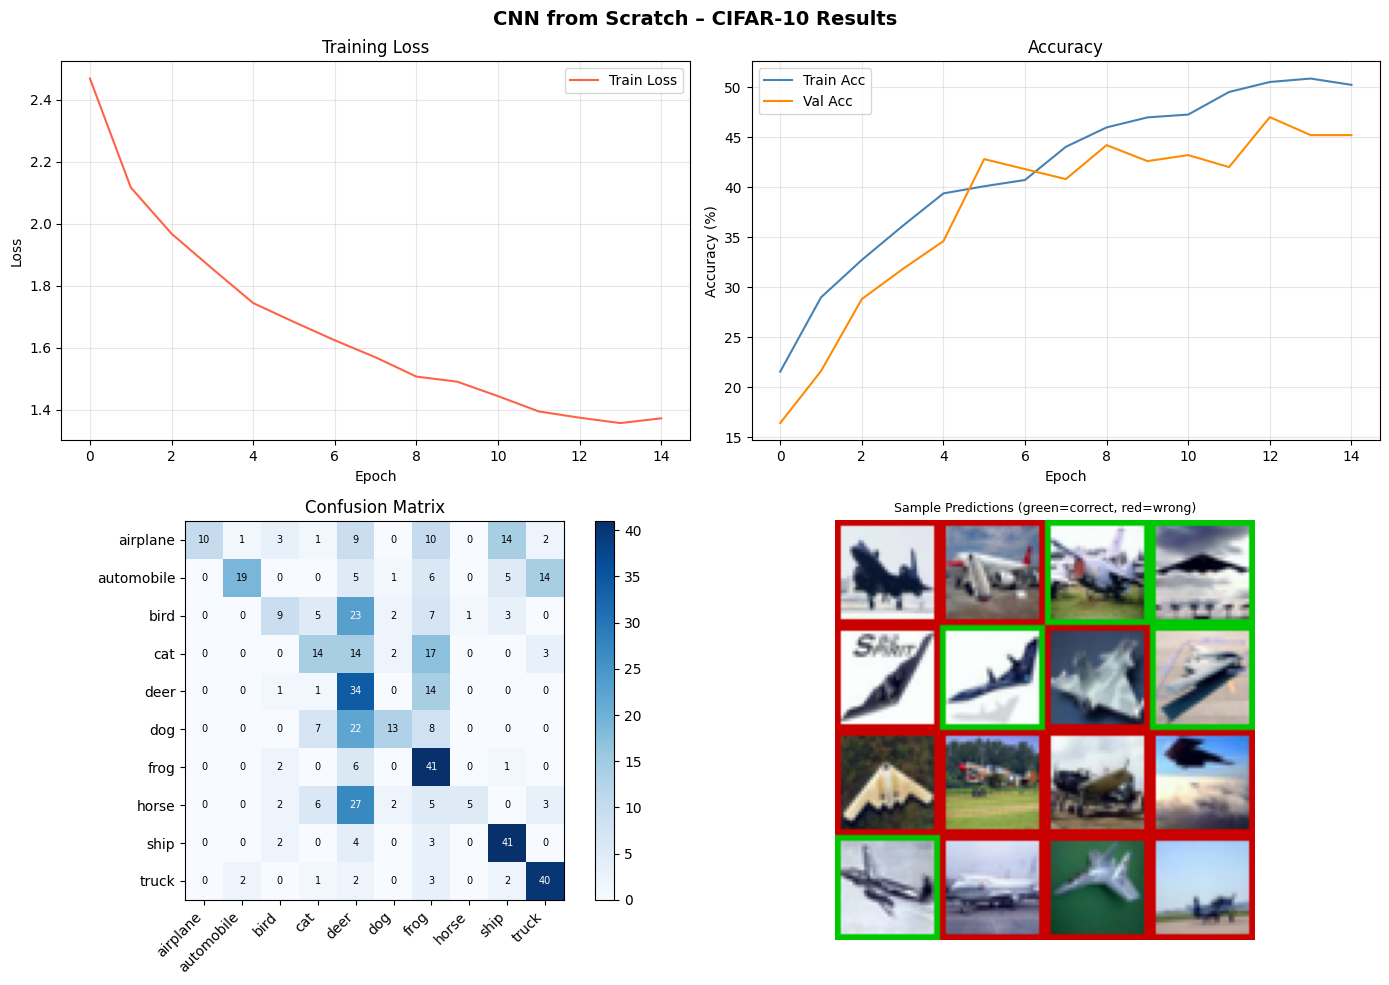


Plot saved as cnn_results.png


In [67]:
plot_results(history, conf, X_test, y_test, all_preds)

**Single Image Inference:**

In [68]:
model.set_training(False)
single = X_test[0:1]
logits = model.forward(single)
shifted = logits - logits.max(axis=1, keepdims=True)
probs = np.exp(shifted) / np.exp(shifted).sum(axis=1, keepdims=True)
pred_class = probs.argmax()
true_class = y_test[0]

print(f"True label : {CLASS_NAMES[true_class]}")
print(f"Predicted  : {CLASS_NAMES[pred_class]}  (confidence {probs[0,pred_class]*100:.1f}%)\n")
for i, name in enumerate(CLASS_NAMES):
    bar = '█' * int(probs[0,i]*40)
    print(f"  {name:<12}: {probs[0,i]*100:5.1f}% {bar}")

True label : airplane
Predicted  : frog  (confidence 22.8%)

  airplane    :  17.1% ██████
  automobile  :   3.8% █
  bird        :   4.4% █
  cat         :   4.8% █
  deer        :  14.4% █████
  dog         :   1.0% 
  frog        :  22.8% █████████
  horse       :   9.4% ███
  ship        :   1.9% 
  truck       :  20.4% ████████
